# Final Project submitted by 
Mahnaz - 10753

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from plotly.offline import iplot, plot
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("/kaggle/input/hr-analytics-job-change-of-data-scientists/aug_train.csv")
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


# Data overview and preprocessing

In [3]:
df.shape

(19158, 14)

In [4]:
# Null counts & Data Types for all features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [5]:
# Missing  Values Percentage
df.isna().sum()*100/df.shape[0]

enrollee_id                0.000000
city                       0.000000
city_development_index     0.000000
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
last_new_job               2.207955
training_hours             0.000000
target                     0.000000
dtype: float64

In [6]:
# show distribution of  gender by education_level
df.groupby('education_level').gender.value_counts()

education_level  gender
Graduate         Male      8144
                 Female     773
                 Other      112
High School      Male      1395
                 Female      67
                 Other       33
Masters          Male      2957
                 Female     339
                 Other       27
Phd              Male       280
                 Female      47
                 Other        4
Primary School   Male       203
                 Other        6
                 Female       4
Name: count, dtype: int64

In [7]:
# Missing  Values Percentage
percent_missing = df.isnull().sum() * 100 / len(df)
missing_value_df = pd.DataFrame({'column_name': df.columns,
                                 'percent_missing': percent_missing})

<BarContainer object of 14 artists>

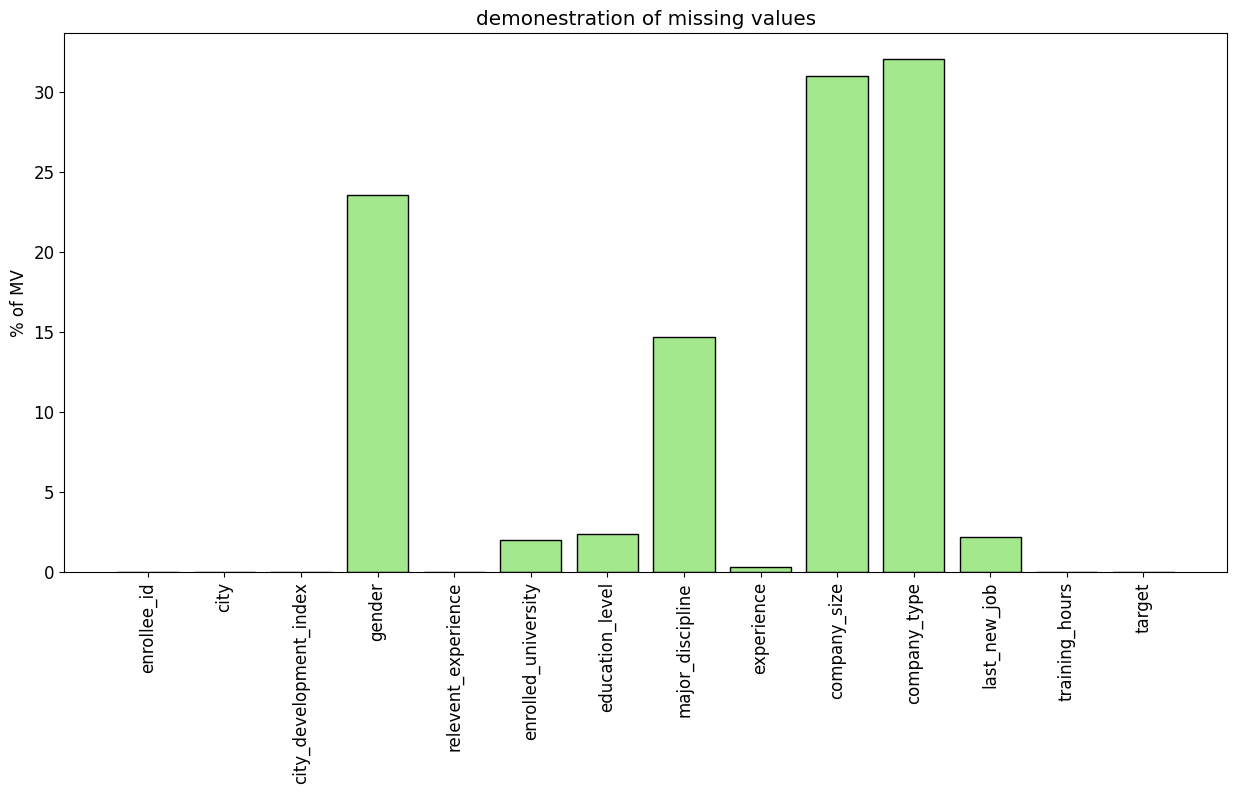

In [8]:
#representing missing values in figure (Bar shape)
plt.figure(figsize = (15,7))
plt.rcParams.update({'font.size':12})
plt.xticks(rotation=90)
plt.title("demonestration of missing values")
plt.ylabel("% of MV") #MV missing values
plt.bar(missing_value_df["column_name"],missing_value_df["percent_missing"],color=(0.6, 0.9, 0.5, 0.9),edgecolor='black')

In [9]:
# Splitting up numerical & categorical columns
df_categorical = df.select_dtypes(include='object')
df_numerical = df.select_dtypes(exclude='object')
# Returns five point summary for  numerical columns
df_numerical.describe()


,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


In [10]:
# Returns summary statistics for categorical columns
df_categorical.describe()

,city,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job
count,19158,14650,19158,18772,18698,16345,19093,13220,13018,18735
unique,123,3,2,3,5,6,22,8,6,6
top,city_103,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,1
freq,4355,13221,13792,13817,11598,14492,3286,3083,9817,8040


In [11]:
df.mode()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,1,city_103,0.92,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,1,28.0,0.0
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,33375,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19154,33376,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19155,33377,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19156,33379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data cleaning

In [12]:
df.isna().sum()*100/df.shape[0]

enrollee_id                0.000000
city                       0.000000
city_development_index     0.000000
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
last_new_job               2.207955
training_hours             0.000000
target                     0.000000
dtype: float64

In [13]:
df.drop(['enrollee_id','city', 'company_size'], axis=1, inplace=True)
df.head()

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_type,last_new_job,training_hours,target
0,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,1,36,1.0
1,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,Pvt Ltd,>4,47,0.0
2,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,never,83,0.0
3,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,Pvt Ltd,never,52,1.0
4,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,Funded Startup,4,8,0.0


In [14]:
df.isnull().any()

city_development_index    False
gender                     True
relevent_experience       False
enrolled_university        True
education_level            True
major_discipline           True
experience                 True
company_type               True
last_new_job               True
training_hours            False
target                    False
dtype: bool

****

In [15]:
# We we use interpolate method to see if we can handle numerical  missing values
df.isnull().sum()

city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [16]:
def clean_experience(df):
    for i in df["experience"]:
        if i == ">20":
            df.loc[df["experience"] == i, "experience"] = 27
        elif i == "<1":
            df.loc[df["experience"] == i, "experience"] = 0

    df["experience"].fillna(0, inplace=True)
    df["experience"] = df['experience'].astype(int)


In [17]:
def clean_NAN(df):
    df["gender"].fillna("Unknown", inplace=True)
    df["education_level"].fillna("Unknown", inplace=True)
    df["major_discipline"].fillna("Unknown", inplace=True)
    df["experience"].fillna(df["experience"].mean(), inplace=True)
    df["company_type"].fillna("Unknown", inplace=True)


In [18]:
def clean_company_size(df):
    df["company_size"].replace({"10/49": "10-49", "<10": "1-9", "10000+": "10000-20000"}, inplace=True)
    df["company_size"].fillna("0-0", inplace=True)
    df[['company_size_min', 'company_size_max']] = df['company_size'].str.split("-", n=1, expand=True)
    df["company_size_min"] = df["company_size_min"].astype(int)
    df["company_size_max"] = df["company_size_max"].astype(int)


In [19]:
def clean_last_new_job(df):
    for i, val in enumerate(df["last_new_job"]):
        if val == "never" or pd.isnull(val):
            df.at[i, "last_new_job"] = 0
        elif val == ">4":
            df.at[i, "last_new_job"] = 6

    df["last_new_job"].fillna(0, inplace=True)
    df["last_new_job"] = df["last_new_job"].astype(int)


In [20]:
def clean_relevent_experience(df):
    df["relevent_experience"] = df["relevent_experience"].replace({"Has relevent experience": 1, "No relevent experience": 0})


In [21]:
def clean_data(df):
    clean_experience(df)
    clean_NAN(df)
    clean_last_new_job(df)

    clean_relevent_experience(df)
  
    return df

In [22]:
df = clean_data(df)
df.head()

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_type,last_new_job,training_hours,target
0,0.920,Male,1,no_enrollment,Graduate,STEM,27,Unknown,1,36,1.0
1,0.776,Male,0,no_enrollment,Graduate,STEM,15,Pvt Ltd,6,47,0.0
2,0.624,Unknown,0,Full time course,Graduate,STEM,5,Unknown,0,83,0.0
3,0.789,Unknown,0,NaN,Graduate,Business Degree,0,Pvt Ltd,0,52,1.0
4,0.767,Male,1,no_enrollment,Masters,STEM,27,Funded Startup,4,8,0.0


In [23]:
df.isnull().any()

city_development_index    False
gender                    False
relevent_experience       False
enrolled_university        True
education_level           False
major_discipline          False
experience                False
company_type              False
last_new_job              False
training_hours            False
target                    False
dtype: bool

In [24]:
# we still have to handle missing values of education which is categorical
df.enrolled_university.unique()

array(['no_enrollment', 'Full time course', nan, 'Part time course'],
      dtype=object)

In [25]:
df['enrolled_university'] = df['enrolled_university'].fillna(method='bfill')

In [26]:
df.isnull().any()

city_development_index    False
gender                    False
relevent_experience       False
enrolled_university       False
education_level           False
major_discipline          False
experience                False
company_type              False
last_new_job              False
training_hours            False
target                    False
dtype: bool

In [27]:
# Data Preprocessing for model building
df.head(8)

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_type,last_new_job,training_hours,target
0,0.920,Male,1,no_enrollment,Graduate,STEM,27,Unknown,1,36,1.0
1,0.776,Male,0,no_enrollment,Graduate,STEM,15,Pvt Ltd,6,47,0.0
2,0.624,Unknown,0,Full time course,Graduate,STEM,5,Unknown,0,83,0.0
3,0.789,Unknown,0,no_enrollment,Graduate,Business Degree,0,Pvt Ltd,0,52,1.0
4,0.767,Male,1,no_enrollment,Masters,STEM,27,Funded Startup,4,8,0.0
5,0.764,Unknown,1,Part time course,Graduate,STEM,11,Unknown,1,24,1.0
6,0.920,Male,1,no_enrollment,High School,Unknown,5,Funded Startup,1,24,0.0
7,0.762,Male,1,no_enrollment,Graduate,STEM,13,Pvt Ltd,6,18,1.0


In [28]:

# Replace 'Other' and 'unkown' with 'Pvt Ltd' 
df['company_type'] = df['company_type'].replace({'Other': 'Pvt Ltd'})
df['company_type'] = df['company_type'].replace({'Unknown': 'Pvt Ltd'})
# Replace 'unkown' with 'Female' (dominant)
df['gender'] = df['gender'].replace({'Unknown': 'Female'})
df['education_level'] = df['education_level'].replace({'Unknown': 'Graduate'})


In [29]:

df.drop('major_discipline', axis=1, inplace=True)


In [30]:
df.head(10)

,city_development_index,gender,relevent_experience,enrolled_university,education_level,experience,company_type,last_new_job,training_hours,target
0,0.920,Male,1,no_enrollment,Graduate,27,Pvt Ltd,1,36,1.0
1,0.776,Male,0,no_enrollment,Graduate,15,Pvt Ltd,6,47,0.0
2,0.624,Female,0,Full time course,Graduate,5,Pvt Ltd,0,83,0.0
3,0.789,Female,0,no_enrollment,Graduate,0,Pvt Ltd,0,52,1.0
4,0.767,Male,1,no_enrollment,Masters,27,Funded Startup,4,8,0.0
5,0.764,Female,1,Part time course,Graduate,11,Pvt Ltd,1,24,1.0
6,0.920,Male,1,no_enrollment,High School,5,Funded Startup,1,24,0.0
7,0.762,Male,1,no_enrollment,Graduate,13,Pvt Ltd,6,18,1.0
8,0.920,Male,1,no_enrollment,Graduate,7,Pvt Ltd,1,46,1.0
9,0.920,Female,1,no_enrollment,Graduate,17,Pvt Ltd,6,123,0.0


In [31]:
df.enrolled_university.unique()

array(['no_enrollment', 'Full time course', 'Part time course'],
      dtype=object)

In [32]:
df.gender.unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [33]:
df.education_level.unique()

array(['Graduate', 'Masters', 'High School', 'Phd', 'Primary School'],
      dtype=object)

In [34]:
df.company_type.unique()

array(['Pvt Ltd', 'Funded Startup', 'Early Stage Startup',
       'Public Sector', 'NGO'], dtype=object)

In [35]:
# we should lable our categorical varible to numerical

df['gender'] = df['gender'].replace({'Female': 0, 'Male': 1, 'Other':2}).astype(int)

df['enrolled_university'] = df['enrolled_university'].replace({'no_enrollment': 0, 'Part time course': 1, 'Full time course': 2}).astype(int)

df['education_level'] = df['education_level'].replace({'Primary School':0, 'High School': 1, 'Graduate': 2, 'Masters': 3, 'Phd':4,}).astype(int)

df['company_type'] = df['company_type'].replace({'Pvt Ltd': 0, 'Funded Startup': 1, 'Public Sector':2,
       'Early Stage Startup':3, 'NGO':4}).astype(int)




In [36]:
df.company_type.unique()

array([0, 1, 3, 2, 4])

In [37]:
df.education_level.unique()

array([2, 3, 1, 4, 0])

In [38]:
df.gender.unique()

array([1, 0, 2])

In [39]:
df.education_level.unique()

array([2, 3, 1, 4, 0])

In [40]:
df.last_new_job.unique()

array([1, 6, 0, 4, 3, 2])

In [41]:
df.head()

,city_development_index,gender,relevent_experience,enrolled_university,education_level,experience,company_type,last_new_job,training_hours,target
0,0.920,1,1,0,2,27,0,1,36,1.0
1,0.776,1,0,0,2,15,0,6,47,0.0
2,0.624,0,0,2,2,5,0,0,83,0.0
3,0.789,0,0,0,2,0,0,0,52,1.0
4,0.767,1,1,0,3,27,1,4,8,0.0


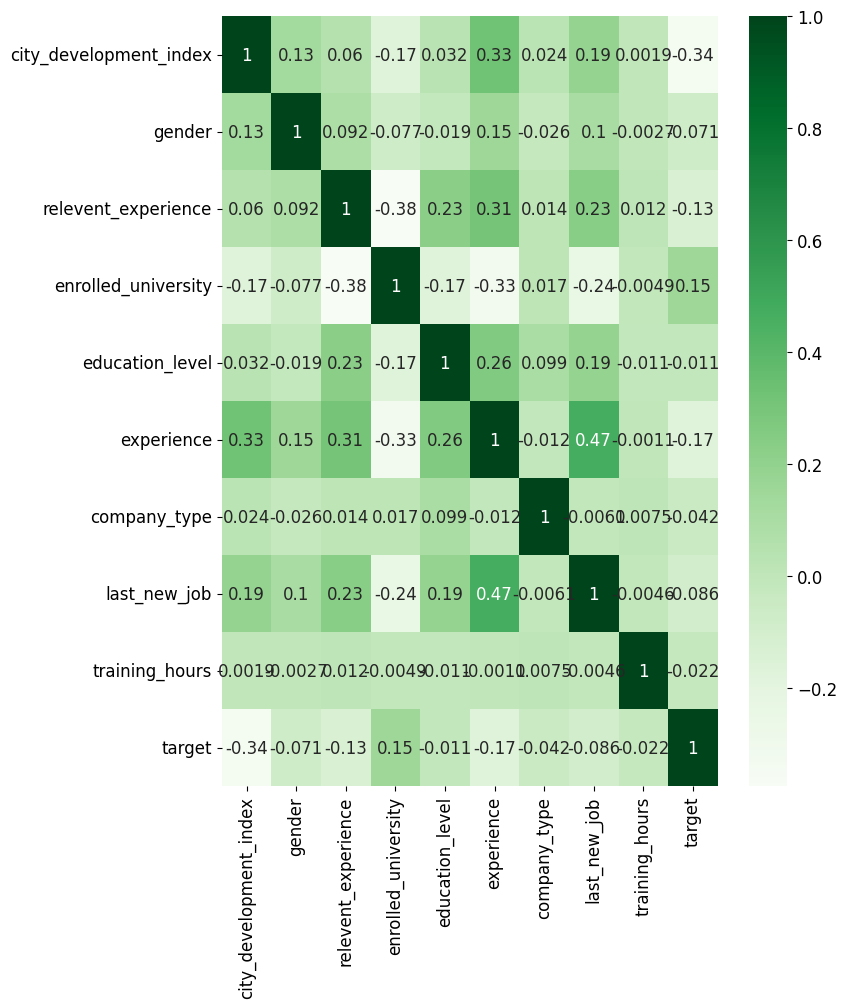

In [42]:
# Let check the corerlation before
plt.figure(figsize=(8,10))
sns.heatmap(df.corr(),annot=True,cmap='Greens')
plt.show()

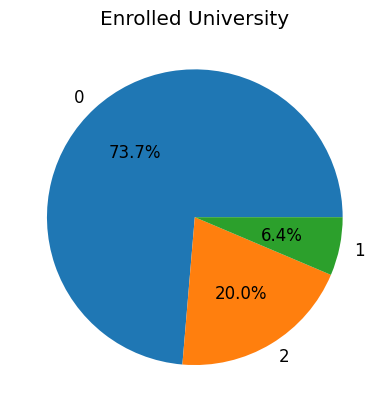

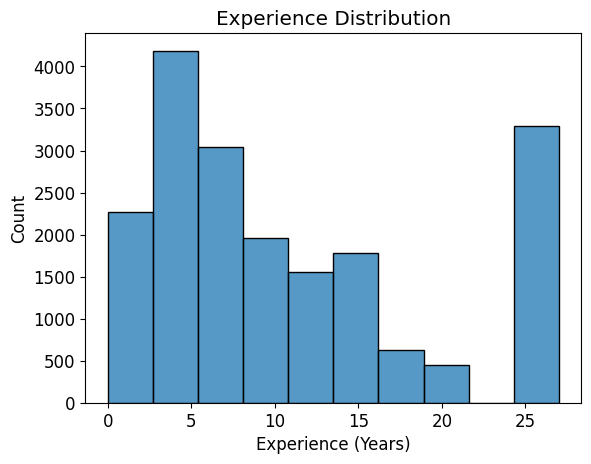

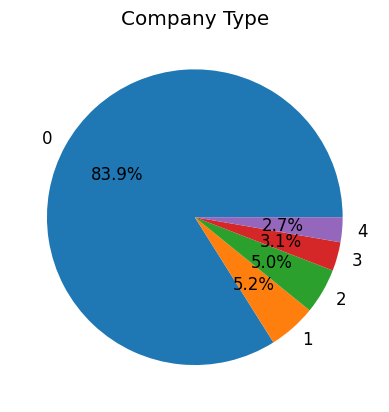

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Function to set common plot attributes
def set_plot_attributes(title, xlabel, ylabel):
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# Enrolled University (Pie chart)
enrolled_university_counts = df['enrolled_university'].value_counts()
plt.pie(enrolled_university_counts, labels=enrolled_university_counts.index, autopct='%1.1f%%')
set_plot_attributes('Enrolled University', None, None)

# Experience (Histogram)
sns.histplot(data=df, x='experience', bins=10)
set_plot_attributes('Experience Distribution', 'Experience (Years)', 'Count')


# Company Type (Pie chart)
company_type_counts = df['company_type'].value_counts()
plt.pie(company_type_counts, labels=company_type_counts.index, autopct='%1.1f%%')
set_plot_attributes('Company Type', None, None)


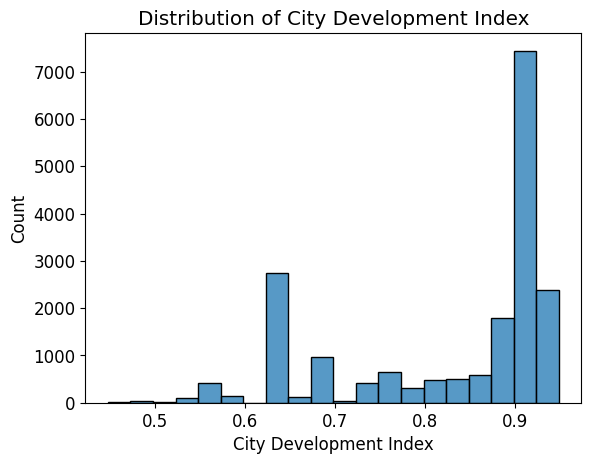

In [44]:
import plotly.express as px

sns.histplot(data=df, x='city_development_index', bins=20)
plt.title('Distribution of City Development Index')
plt.xlabel('City Development Index')
plt.ylabel('Count')
plt.show()

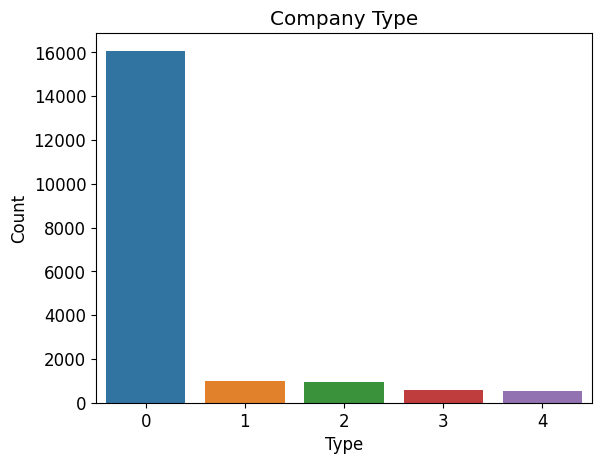

In [45]:
# Company Type (Pie chart)
sns.countplot(data=df, x='company_type')
plt.title('Company Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

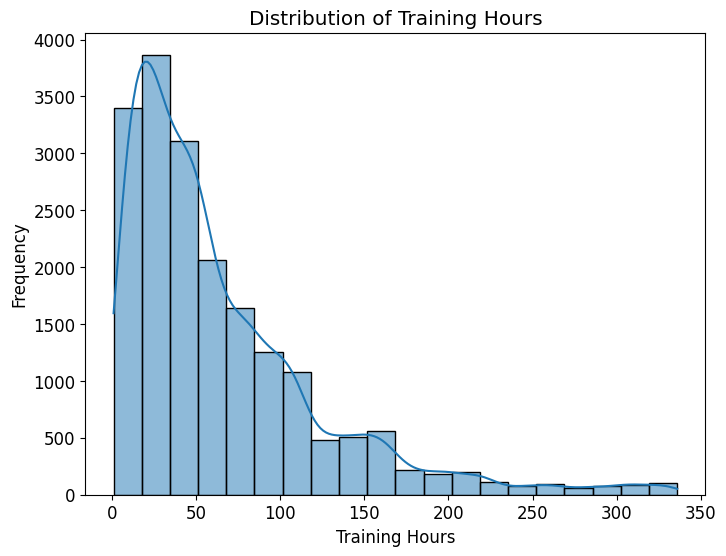

In [46]:
plt.figure(figsize=(8, 6))
sns.histplot(df['training_hours'], bins=20, kde=True)
plt.title('Distribution of Training Hours')
plt.xlabel('Training Hours')
plt.ylabel('Frequency')
plt.show()

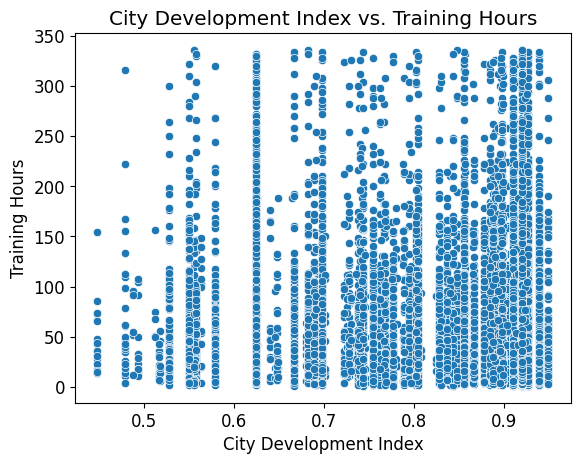

In [47]:
sns.scatterplot(data=df, x='city_development_index', y='training_hours')
plt.title('City Development Index vs. Training Hours')
plt.xlabel('City Development Index')
plt.ylabel('Training Hours')
plt.show()


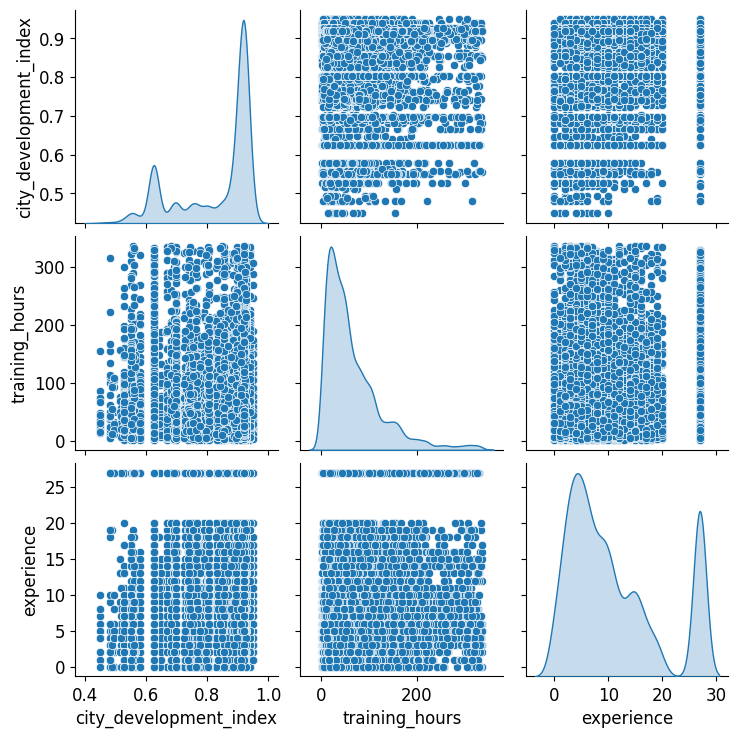

In [48]:
sns.pairplot(df[['city_development_index', 'training_hours', 'experience']], diag_kind='kde')
plt.show()

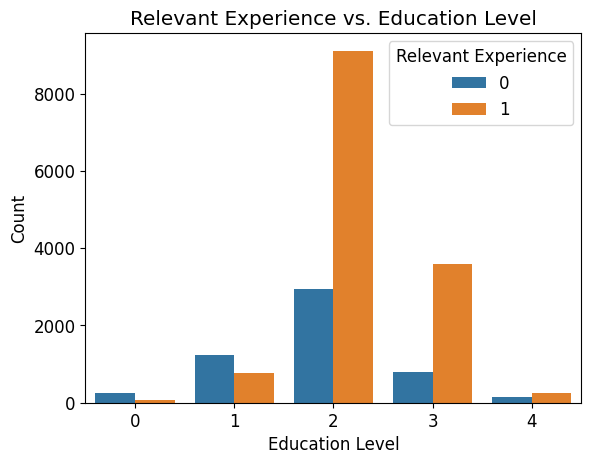

In [49]:
sns.countplot(data=df, x='education_level', hue='relevent_experience')
plt.title('Relevant Experience vs. Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.legend(title='Relevant Experience')
plt.show()


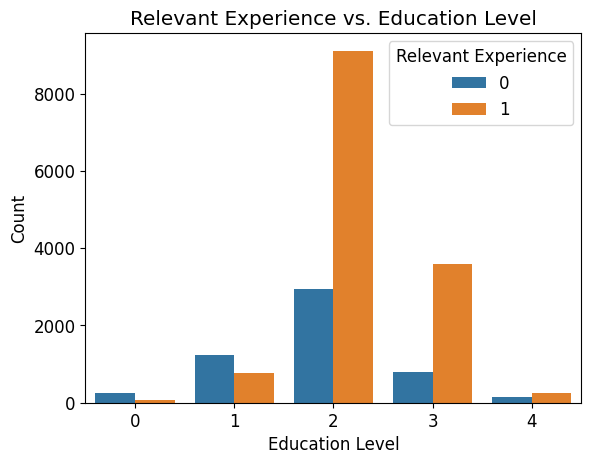

In [50]:
# Relevant Experience vs. Education Level (Stacked bar plot)
sns.countplot(data=df, x='education_level', hue='relevent_experience')
plt.title('Relevant Experience vs. Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.legend(title='Relevant Experience')
plt.show()

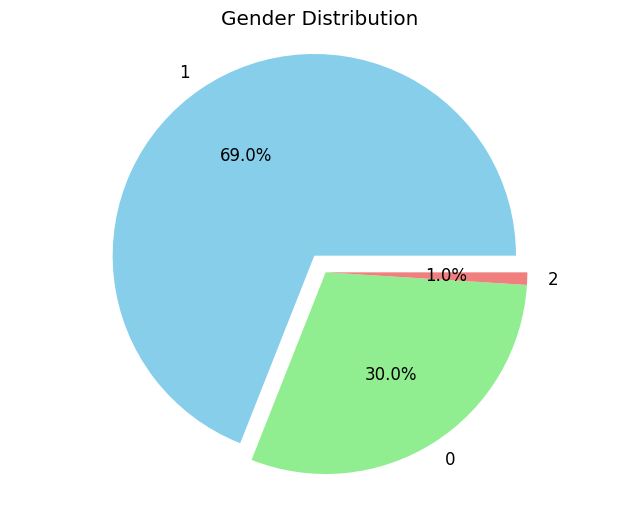

In [51]:
# Pie chart: Gender Distribution
plt.figure(figsize=(8, 6))
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightgreen', 'lightcoral'], explode=(0.1, 0, 0))
plt.title('Gender Distribution')
plt.ylabel('')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()


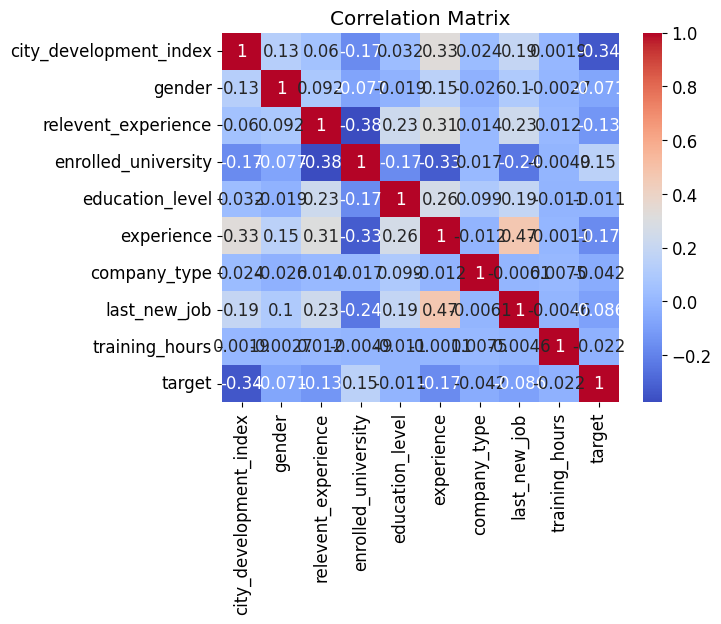

In [52]:

correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# feature selection and Model building

In [53]:

# Splitting our data into x and y
x=df.drop('target',axis=1)
y=df['target'] # this is our dependent variable

In [54]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2, random_state=0 )

In [55]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()
X_train = scaler.fit_transform(xtrain)
x_test = scaler.fit_transform(xtrain)

In [56]:
logit=LogisticRegression()
logit.fit(xtrain,ytrain)



LogisticRegression()

# Model Accuracy Checking

In [57]:
logit.score(xtrain,ytrain)
logit.score(xtrain,ytrain)

0.7623646091609031

In [58]:
ypred=logit.predict(xtest)
ypred

array([0., 0., 0., ..., 0., 0., 1.])

<Axes: >

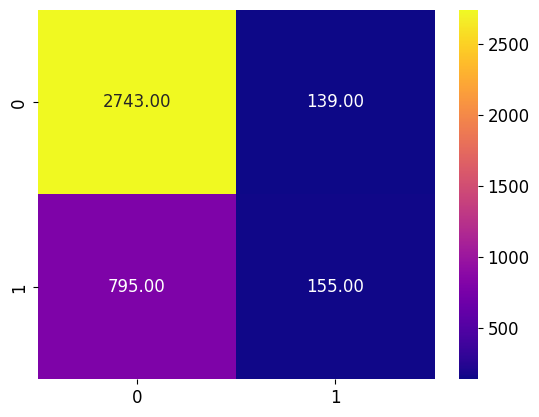

In [59]:
sns.heatmap(confusion_matrix(ytest,ypred), annot=True, cmap='plasma', fmt=".2f")

In [60]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

         0.0       0.78      0.95      0.85      2882
         1.0       0.53      0.16      0.25       950

    accuracy                           0.76      3832
   macro avg       0.65      0.56      0.55      3832
weighted avg       0.71      0.76      0.70      3832



In [61]:


print('confusion matrix :',confusion_matrix(ytest,ypred))

print('accuracy :',accuracy_score(ytest,ypred))
print('precision :',precision_score(ytest,ypred))



confusion matrix : [[2743  139]
 [ 795  155]]
accuracy : 0.7562630480167014
precision : 0.5272108843537415


In [62]:
from xgboost.sklearn import XGBClassifier
#xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2, random_state=42 )

xgb = XGBClassifier()

xgb.fit(xtrain,ytrain)

y_train_pred = xgb.predict(xtrain)
y_train_prob = xgb.predict_proba(xtrain)[:,1]

print(round(accuracy_score(ytrain,y_train_pred),2))


0.85


In [63]:
# for this data i use two accuracy model xgboost which shows accuracy 85 and logisticregression which shows 75 less than the prediction that i was expected.(my goal was 80)